# Global Petrol & Gas Price Analysis (2015–Present)

**Name:** Suraj R Bhandare  
**Roll No:** SA260

---

## Problem Statement

I am analyzing global petrol and gas prices to understand how different factors like crude oil prices, demand, supply, and geopolitical risks affect fuel prices. This study helps identify patterns and predict price changes in real-world scenarios.

Dataset Name: Global Petrol & Gas Price Analysis  
Source: Kaggle  

Rows: 5860
Columns: 22  

---

## Column Description

- Date: Observation date  
- Country: Country name  
- Region: Geographic region  
- Petrol_Price_USD_per_Liter: Petrol price  
- Diesel_Price_USD_per_Liter: Diesel price  
- Natural_Gas_Price_USD_per_MMBtu: Gas price  
- Crude_Oil_Price_USD_per_Barrel: Crude oil price  
- Inflation_Rate (%): Inflation rate  
- Exchange_Rate_vs_USD: Currency exchange rate  
- GDP_Growth (%): Economic growth  
- Supply_Index: Supply level  
- Demand_Index: Demand level  
- Geopolitical_Risk_Index: Global risk factor  
- Event_Flag: Event occurrence (0/1)  
- Event_Description: Event details  
- Currency_Devaluation (%): Currency change  
- Subsidy_Level: Government subsidy  
- Tax_Rate_on_Fuel (%): Fuel tax  
- Petrol_7d_MA: Moving average  
- Petrol_28d_vol: Volatility  
- Petrol_lag_1: Previous price  
- Crude_lag_1: Previous crude price  


##Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset has been successfully loaded using pandas, and the first 5 rows are displayed to understand its structure.

In [2]:
df = pd.read_csv("petrol_gas_price_analysis_clean.csv")
df.head()

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),...,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
0,2015-01-05,Brazil,Latin America,0.675,0.609,1.769,50.91,2.42,5.1316,0.58,...,20.4,0,NaN,0.32,Medium,20.0,0.675000,NaN,NaN,NaN
1,2015-01-12,Brazil,Latin America,0.687,0.602,1.565,51.57,3.39,5.2201,2.08,...,23.5,0,NaN,-0.41,Medium,20.0,0.681000,NaN,0.675,50.91
2,2015-01-19,Brazil,Latin America,0.710,0.642,1.760,53.96,2.03,5.0857,3.43,...,21.1,0,NaN,0.35,Medium,20.0,0.690667,0.011102,0.687,51.57
3,2015-01-26,Brazil,Latin America,0.802,0.713,1.500,58.69,2.30,5.2486,1.96,...,24.5,0,NaN,-0.46,Medium,20.0,0.718500,0.060526,0.710,53.96
4,2015-02-02,Brazil,Latin America,0.685,0.650,1.500,52.61,1.96,5.2284,1.83,...,25.4,0,NaN,-0.74,Medium,20.0,0.721000,0.114316,0.802,58.69


## Dataset Overview

The dataset contains multiple rows and columns including both numeric and categorical data. It includes time-series data along with economic and geopolitical factors affecting fuel prices.

In [3]:
df.shape

(5860, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             5860 non-null   object 
 1   Country                          5860 non-null   object 
 2   Region                           5860 non-null   object 
 3   Petrol_Price_USD_per_Liter       5860 non-null   float64
 4   Diesel_Price_USD_per_Liter       5860 non-null   float64
 5   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64
 6   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64
 7   Inflation_Rate (%)               5860 non-null   float64
 8   Exchange_Rate_vs_USD             5860 non-null   float64
 9   GDP_Growth (%)                   5860 non-null   float64
 10  Supply_Index                     5860 non-null   float64
 11  Demand_Index                     5860 non-null   float64
 12  Geopolitical_Risk_In

In [5]:
df.dtypes

,0
Date,object
Country,object
Region,object
Petrol_Price_USD_per_Liter,float64
Diesel_Price_USD_per_Liter,float64
Natural_Gas_Price_USD_per_MMBtu,float64
Crude_Oil_Price_USD_per_Barrel,float64
Inflation_Rate (%),float64
Exchange_Rate_vs_USD,float64
GDP_Growth (%),float64


In [6]:
df.isnull().sum()

,0
Date,0
Country,0
Region,0
Petrol_Price_USD_per_Liter,0
Diesel_Price_USD_per_Liter,0
Natural_Gas_Price_USD_per_MMBtu,0
Crude_Oil_Price_USD_per_Barrel,0
Inflation_Rate (%),0
Exchange_Rate_vs_USD,0
GDP_Growth (%),0


## Data Cleaning

The dataset contained missing values in several columns. The 'Event_Description' column had a large number of missing values, which were replaced with "No Event" to indicate the absence of any significant event.

For numerical columns such as petrol volatility and lag features, missing values were handled using appropriate techniques. The 'Petrol_28d_vol' column was filled using the mean value, while lag columns like 'Petrol_lag_1' and 'Crude_lag_1' were filled using backfill to maintain continuity in time-series data.

Duplicate rows were also checked and removed to ensure data accuracy and consistency.

In [7]:
# Fill Event Description separately
df['Event_Description'].fillna("No Event", inplace=True)
df['Petrol_28d_vol'].fillna(df['Petrol_28d_vol'].mean(), inplace=True)
df['Petrol_lag_1'].fillna(method='bfill', inplace=True)
df['Crude_lag_1'].fillna(method='bfill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

/tmp/ipykernel_4935/1221446709.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Event_Description'].fillna("No Event", inplace=True)
/tmp/ipykernel_4935/1221446709.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [8]:
df.isnull().sum()

,0
Date,0
Country,0
Region,0
Petrol_Price_USD_per_Liter,0
Diesel_Price_USD_per_Liter,0
Natural_Gas_Price_USD_per_MMBtu,0
Crude_Oil_Price_USD_per_Barrel,0
Inflation_Rate (%),0
Exchange_Rate_vs_USD,0
GDP_Growth (%),0


## Statistical Analysis

Statistical measures such as mean, median, mode, standard deviation, variance, range, and mid-range were calculated for petrol and crude oil prices.

These measures help in understanding the central tendency and variability of fuel prices. The results show how prices fluctuate over time and indicate the spread and consistency of the data.

In [9]:
# Petrol Price Statistics
petrol = df['Petrol_Price_USD_per_Liter']

print("PETROL PRICE STATS")
print("Mean:", petrol.mean())
print("Median:", petrol.median())
print("Mode:", petrol.mode()[0])
print("Standard Deviation:", petrol.std())
print("Variance:", petrol.var())
print("Range:", petrol.max() - petrol.min())
print("Mid Range:", (petrol.max() + petrol.min()) / 2)


# Crude Oil Price Statistics
crude = df['Crude_Oil_Price_USD_per_Barrel']

print("\nCRUDE OIL PRICE STATS")
print("Mean:", crude.mean())
print("Median:", crude.median())
print("Mode:", crude.mode()[0])
print("Standard Deviation:", crude.std())
print("Variance:", crude.var())
print("Range:", crude.max() - crude.min())
print("Mid Range:", (crude.max() + crude.min()) / 2)

PETROL PRICE STATS
Mean: 0.8386
Median: 0.814
Mode: 0.792
Standard Deviation: 0.19953094270934804
Variance: 0.03981259709848113
Range: 1.22
Mid Range: 0.991

CRUDE OIL PRICE STATS
Mean: 57.44340614334471
Median: 56.745000000000005
Mode: 48.47
Standard Deviation: 9.904935734538546
Variance: 98.10775190533863
Range: 56.25999999999999
Mid Range: 63.72


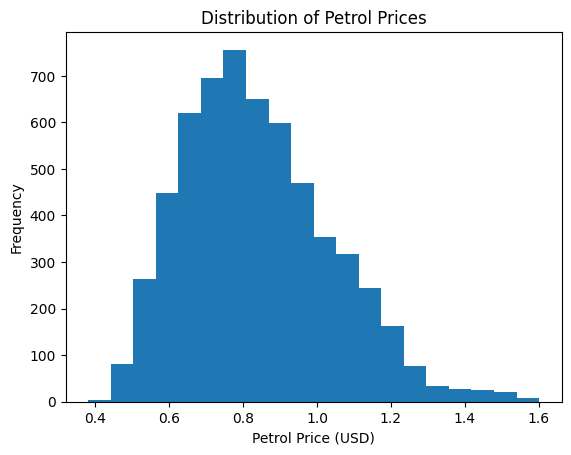

In [10]:
plt.hist(df['Petrol_Price_USD_per_Liter'], bins=20)
plt.title("Distribution of Petrol Prices")
plt.xlabel("Petrol Price (USD)")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most petrol prices fall within a moderate range, with fewer countries having very high prices. This indicates that fuel prices are generally stable, with some variations across regions.

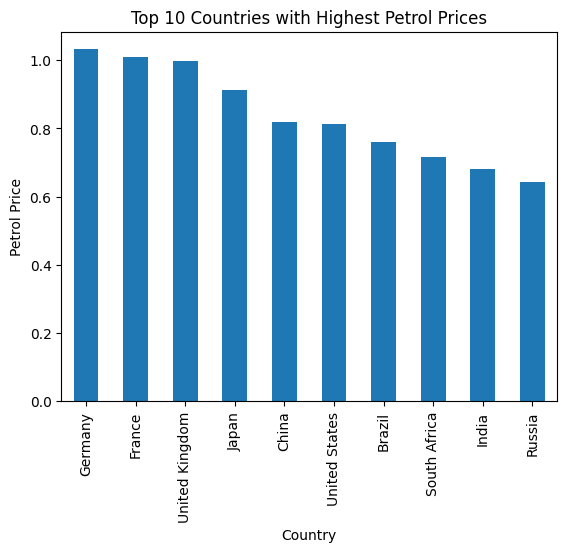

In [11]:

top10 = df.groupby('Country')['Petrol_Price_USD_per_Liter'].mean().sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.title("Top 10 Countries with Highest Petrol Prices")
plt.xlabel("Country")
plt.ylabel("Petrol Price")
plt.show()

This bar chart shows the top 10 countries with the highest petrol prices. It highlights that fuel prices vary across countries, with some countries having significantly higher prices than others.

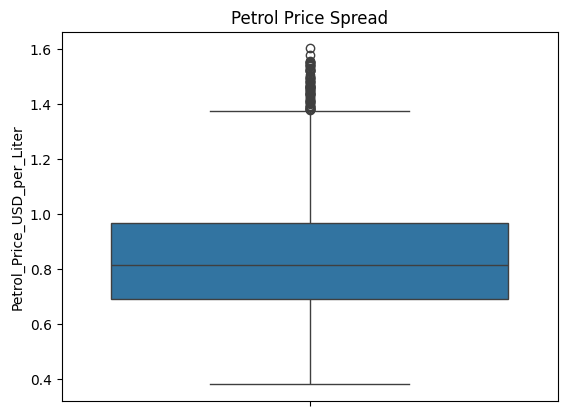

In [12]:
sns.boxplot(y=df['Petrol_Price_USD_per_Liter'])
plt.title("Petrol Price Spread")
plt.show()

The boxplot shows the distribution of petrol prices and highlights the presence of outliers. Most prices fall within a normal range, while some higher values indicate sudden increases in fuel prices.

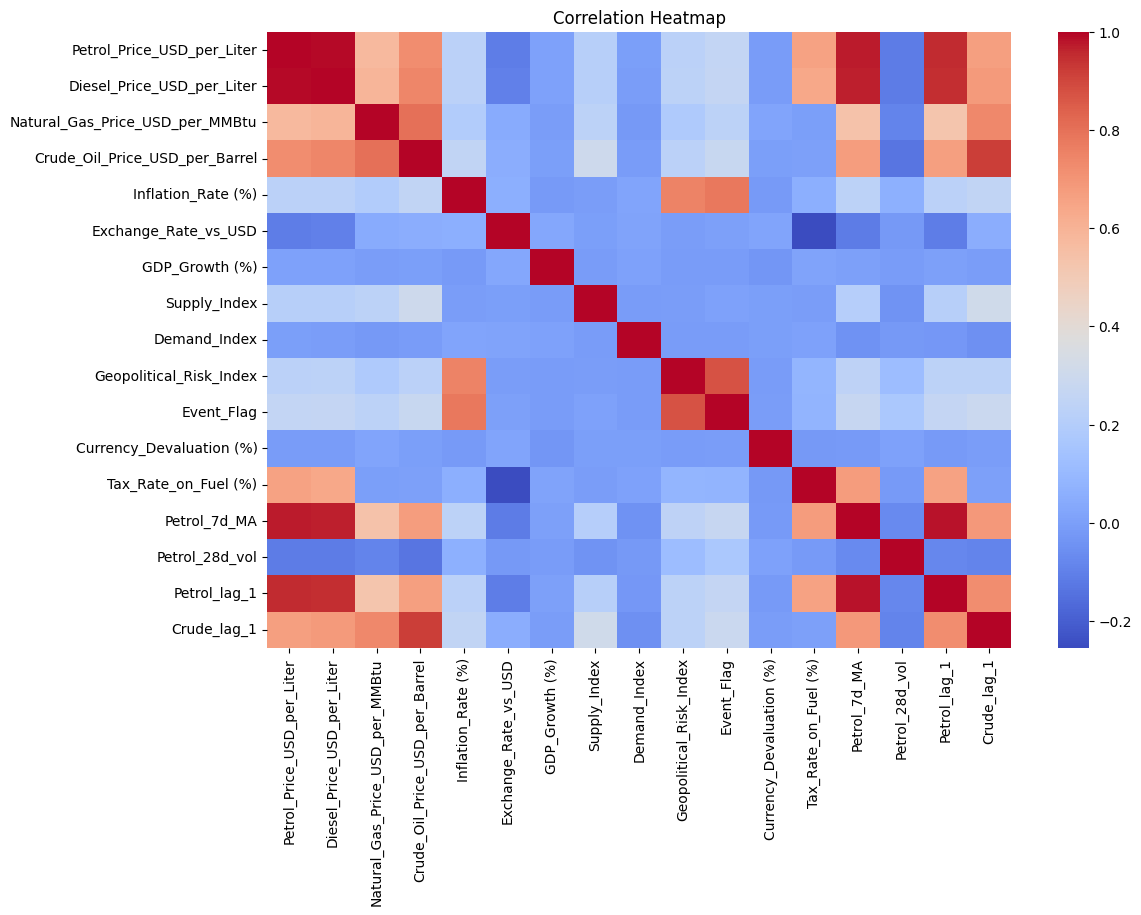

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the relationship between different variables. Petrol prices have a strong positive correlation with crude oil prices and diesel prices, indicating that these factors significantly influence fuel prices.

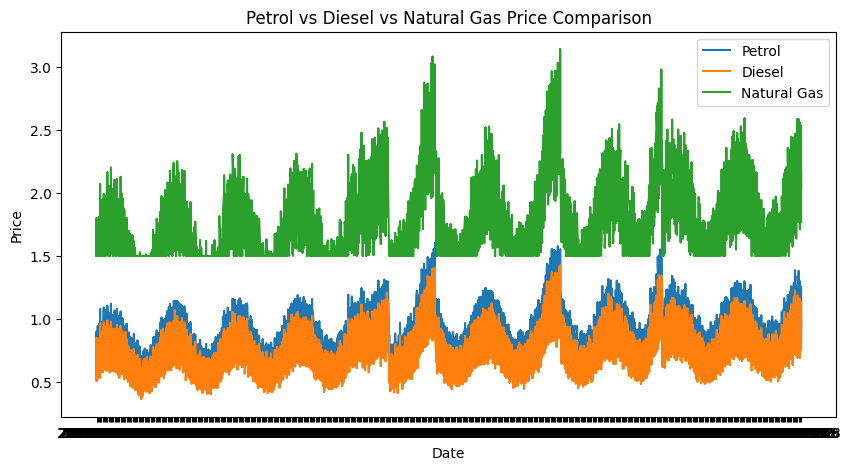

In [14]:
df_sorted = df.sort_values('Date')
plt.figure(figsize=(10,5))
plt.plot(df_sorted['Date'], df_sorted['Petrol_Price_USD_per_Liter'], label='Petrol')
plt.plot(df_sorted['Date'], df_sorted['Diesel_Price_USD_per_Liter'], label='Diesel')
plt.plot(df_sorted['Date'], df_sorted['Natural_Gas_Price_USD_per_MMBtu'], label='Natural Gas')

plt.title("Petrol vs Diesel vs Natural Gas Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

This graph compares petrol, diesel, and natural gas prices over time. Petrol and diesel follow a similar trend, while natural gas shows higher fluctuations, indicating different market behavior.

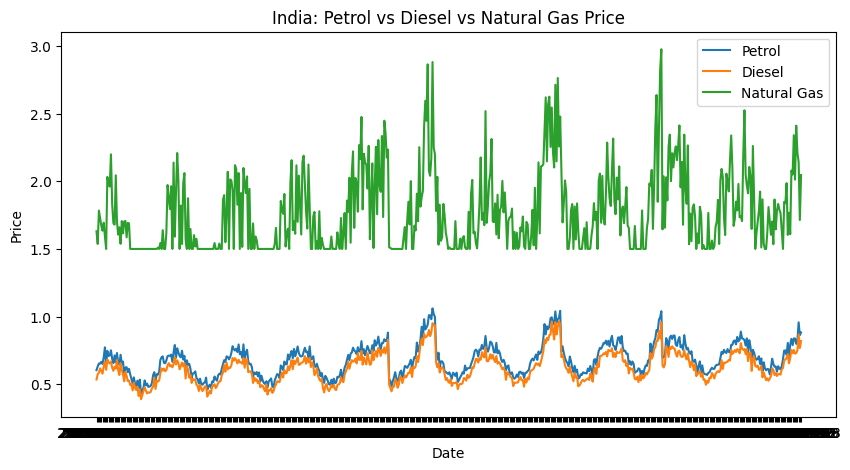

In [15]:

india_df = df[df['Country'] == 'India']
india_df = india_df.sort_values('Date')
plt.figure(figsize=(10,5))

plt.plot(india_df['Date'], india_df['Petrol_Price_USD_per_Liter'], label='Petrol')
plt.plot(india_df['Date'], india_df['Diesel_Price_USD_per_Liter'], label='Diesel')
plt.plot(india_df['Date'], india_df['Natural_Gas_Price_USD_per_MMBtu'], label='Natural Gas')

plt.title("India: Petrol vs Diesel vs Natural Gas Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

This graph shows fuel price trends in India. Petrol prices are generally higher than diesel, and both follow a similar pattern, while natural gas shows more fluctuations.

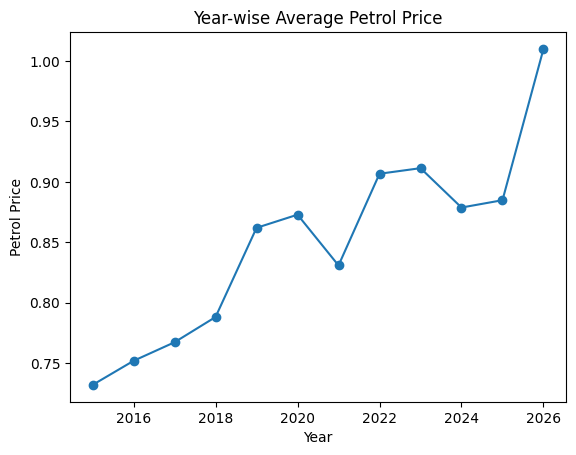

In [16]:
df['Year'] = pd.to_datetime(df['Date']).dt.year

year_avg = df.groupby('Year')['Petrol_Price_USD_per_Liter'].mean()

year_avg.plot(kind='line', marker='o')
plt.title("Year-wise Average Petrol Price")
plt.xlabel("Year")
plt.ylabel("Petrol Price")
plt.show()

This graph shows the yearly trend of petrol prices. It indicates that petrol prices have generally increased over time, reflecting rising demand and economic factors.

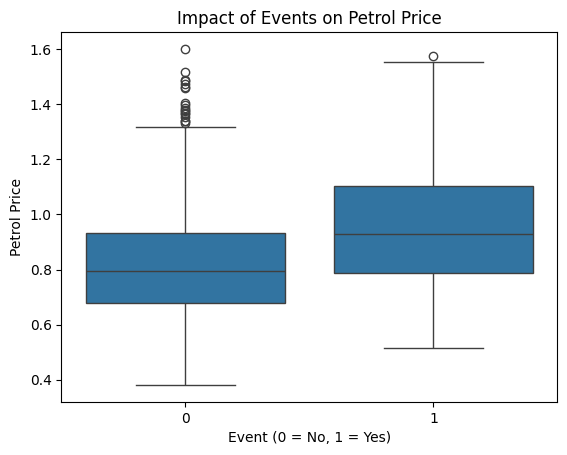

In [17]:
sns.boxplot(x='Event_Flag', y='Petrol_Price_USD_per_Liter', data=df)
plt.title("Impact of Events on Petrol Price")
plt.xlabel("Event (0 = No, 1 = Yes)")
plt.ylabel("Petrol Price")
plt.show()

This graph compares petrol prices during normal periods and during global events. It shows that prices tend to be higher during events, indicating the impact of external factors on fuel prices.

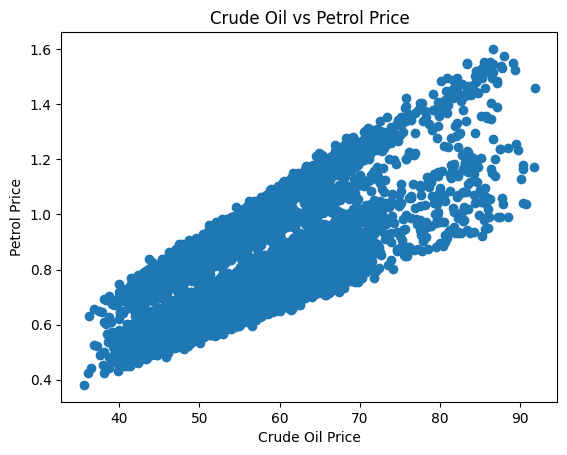

In [18]:
plt.scatter(df['Crude_Oil_Price_USD_per_Barrel'], df['Petrol_Price_USD_per_Liter'])
plt.title("Crude Oil vs Petrol Price")
plt.xlabel("Crude Oil Price")
plt.ylabel("Petrol Price")
plt.show()

This scatter plot shows a positive relationship between crude oil prices and petrol prices. As crude oil prices increase, petrol prices also tend to increase.

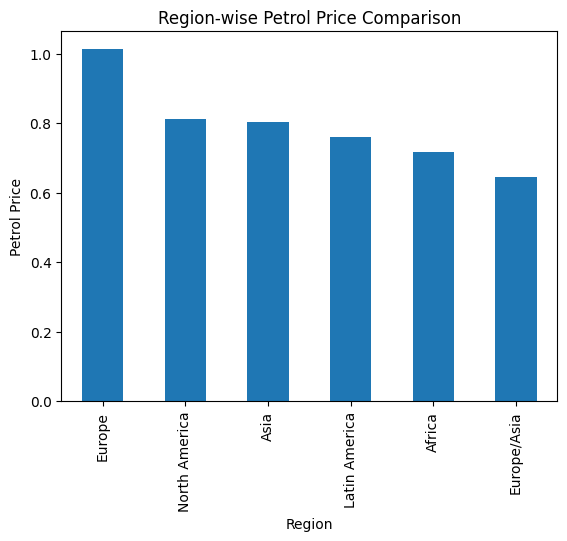

In [19]:
region_avg = df.groupby('Region')['Petrol_Price_USD_per_Liter'].mean().sort_values(ascending=False)

region_avg.plot(kind='bar')
plt.title("Region-wise Petrol Price Comparison")
plt.xlabel("Region")
plt.ylabel("Petrol Price")
plt.show()

This graph compares average petrol prices across different regions. It shows that fuel prices vary by region, with some regions having higher prices due to economic conditions and fuel policies.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_ml = df.copy()

# Remove problematic columns
df_ml = df_ml.drop(columns=['Date', 'Event_Description', 'Month'], errors='ignore')

# Convert categorical to numeric
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Remove missing values
df_ml = df_ml.dropna()

# Features & Target
X = df_ml.drop('Petrol_Price_USD_per_Liter', axis=1)
y = df_ml['Petrol_Price_USD_per_Liter']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Accuracy
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.9896663387289769


The model achieved a high accuracy score, indicating that it can effectively predict petrol prices based on the given features. However, some features are closely related to petrol prices, which may lead to very high accuracy. Overall, the model demonstrates a strong relationship between input variables and petrol prices.

## Insights

1. The histogram shows that most petrol prices are concentrated in a moderate range, indicating that fuel prices are generally stable with a few high-price outliers.

2. The bar chart of top 10 countries shows that certain countries have significantly higher petrol prices, suggesting the impact of higher taxes and import dependency.

3. The boxplot shows the spread of petrol prices and highlights the presence of outliers, indicating sudden spikes in prices in some cases.

4. The correlation heatmap shows a strong positive relationship between petrol prices and crude oil prices, indicating that crude oil is a major influencing factor.

5. The comparison graph of petrol, diesel, and natural gas shows that petrol and diesel follow similar trends, while natural gas is more volatile.

6. The India-specific graph shows that petrol prices are consistently higher than diesel, and both follow a similar trend over time.

7. The year-wise trend graph shows a gradual increase in petrol prices over the years, indicating rising demand and economic impact.

8. The event impact boxplot shows that petrol prices are generally higher during global events, indicating the influence of geopolitical factors.

9. The scatter plot between crude oil and petrol prices shows a strong positive correlation, confirming that petrol prices increase with crude oil prices.

10. The region-wise bar chart shows that petrol prices vary across regions, indicating differences in economic conditions, taxation, and fuel policies.

## Recommendations

1. Governments should regulate fuel taxes during periods of rising crude oil prices to reduce the financial burden on consumers.

2. Countries should invest in alternative and renewable energy sources to reduce dependence on crude oil and stabilize fuel prices.
3. Countries should maintain strategic fuel reserves to handle sudden price spikes caused by global events or supply disruptions.